In [ ]:
https://www.kaggle.com/datasets/ashydv/advertising-dataset

In [3]:
# scikit-learn 설치 및 버전 확인
%pip install scikit-learn

import sklearn
sklearn.__version__


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     --------------------------------- ------ 51.2/61.0 kB 2.6 MB/s eta 0:00:01
     ---------------------------------------- 61.0/61.0 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 11.1 MB/s eta 0:00:01
   ----- ---------------------------------- 1.1/8.1 MB 9.7 MB/s eta 0:00:01
   -------- ------------------------------- 1.7/8.1 MB 10.6 MB/s eta 0:00:01
   ----------- ---------------------------- 2.3/8.1 MB 10.6 MB/s eta 0:00:01
   --------------- ------------------------ 3.0/8.1 MB 10.8 MB/s eta 0:00:01
   ----------------- ---------------------- 3.6/8.1 MB 10.9 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 10.7 MB/s eta 0:00:01
   ---------------------- ----------------- 4.6/8.1 MB 9.8 MB/s eta 0:00:01
   -------------------------- ------------- 5.3/8.1 MB 10.2 MB/s eta 0:00:01
   -----

'1.8.0'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
plt.style.use('ggplot')

In [5]:
import pandas as pd
 
# TODO: advertising.csv 파일을 읽어와서 5개의 레코드를 출력
advertising = pd.read_csv('data/advertising.csv')
# TODO 2
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
# TODO: 데이터프레임 정보 확인하기

advertising.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
# TODO: 통계정보 확인하기

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
advertising.describe.T()# TODO: 통계 정보 행과 열 바꾸기

AttributeError: 'function' object has no attribute 'T'

In [11]:
advertising.describe().T
# TODO: 컬럼간의 상관계수 확인하기

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


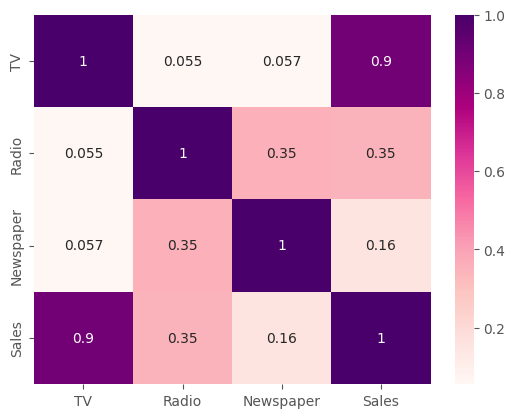

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

corrMatrix = advertising.corr()
sns.heatmap(corrMatrix, annot=True, cmap='RdPu')
plt.show()

In [9]:
# 히트맵을 기준으로 상관 관계가 높은 속성을 내림 차순으로 정렬하여 시각화

corr_sort = corrMatrix[['Sales']].sort_values(by='Sales', ascending= False)
corr_sort

,Sales
Sales,1.000000
TV,0.901208
Radio,0.349631
Newspaper,0.157960


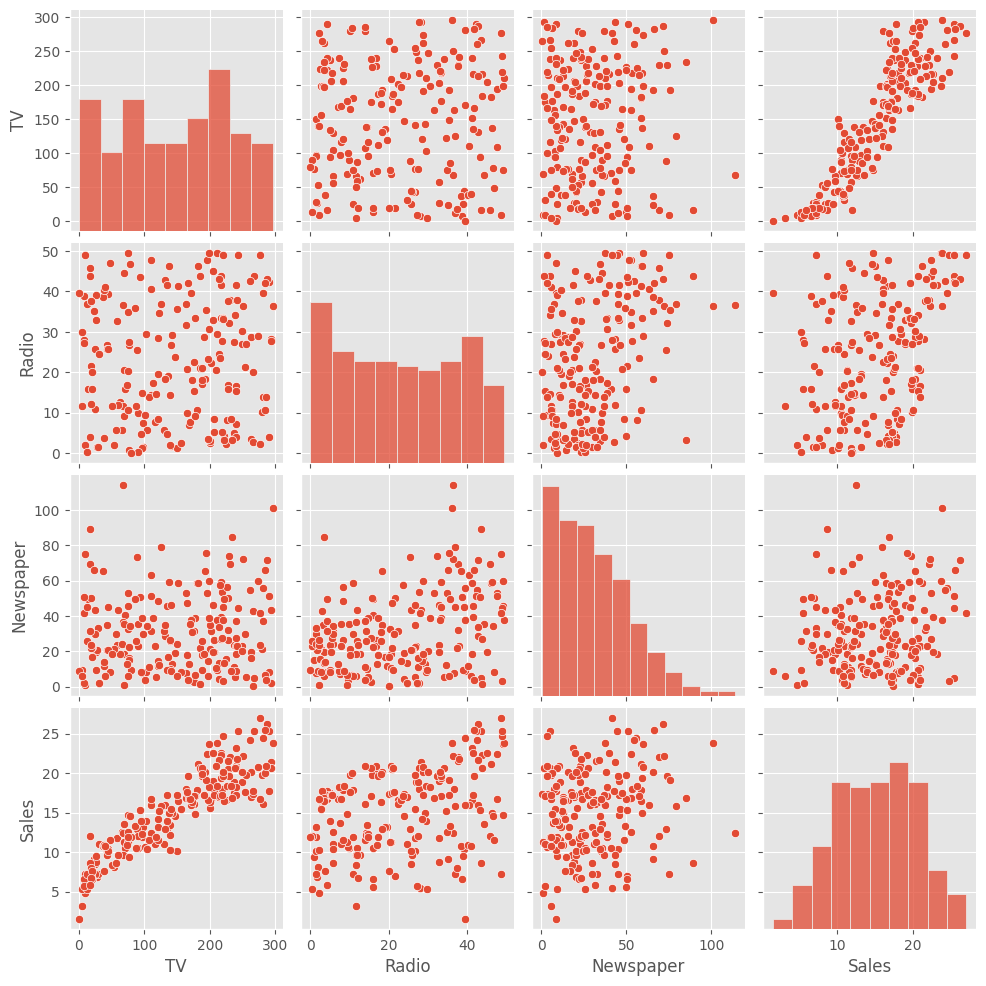

In [10]:
sns.pairplot(advertising)
plt.show()

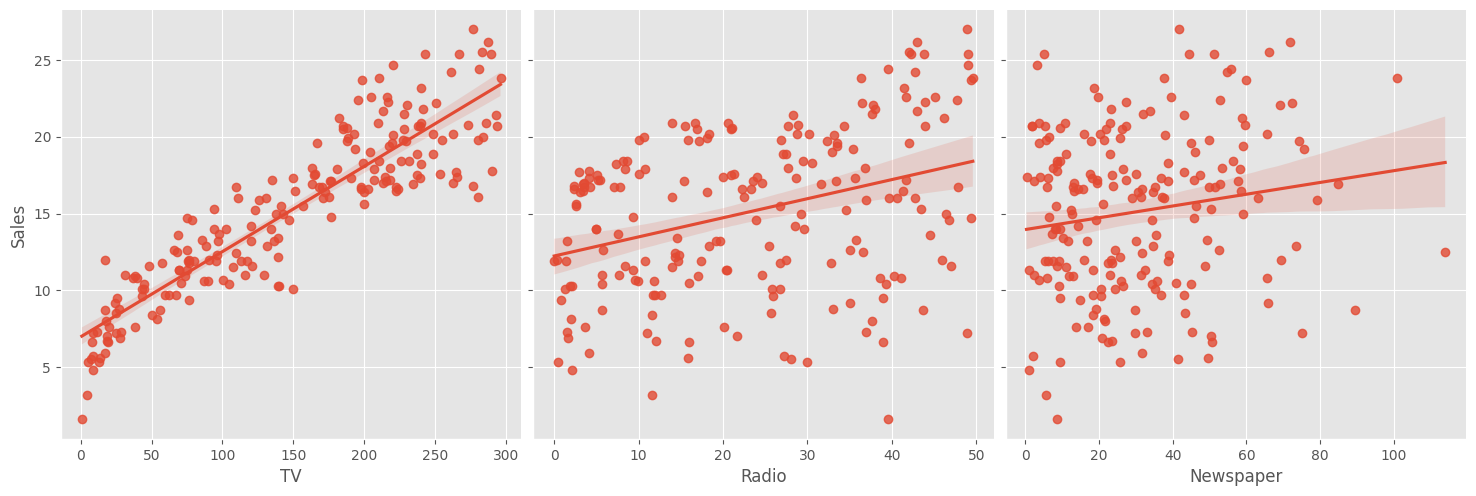

In [21]:
# 'TV', 'Radio', 'Newspaper'의 판매량 pairplot의 세개의 그래프만 그리면서 산점도와 함께 선형회귀선 포함하여 시각화하기

sns.pairplot(data=advertising, x_vars=['TV','Radio','Newspaper'], y_vars='Sales',kind='reg', height=5) #TODO:YOUR_CODE_HERE
plt.show()

In [ ]:
산점도로 판매량을 보고 회귀선을 그려보니 TV가 판매량에 가장 영향을 많이 주고 있다는 것을 알 수  있다.

### 단순 선형 회귀

In [22]:
# 단순 선형 회귀로 모델 학습하고 평가하기
advertising

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [27]:
#독립변수로 TV 컬럼만 가져온다.
X_data1 = advertising[['TV']]

#종속변수로 Sales 데이터를 가져온다
y_data1 = advertising['Sales']
print(type(X_data1), type(y_data1))

<class 'pandas.DataFrame'> <class 'pandas.Series'>


In [30]:
# 훈련 데이터와 테스트 데이터를 7:3 비율로 나누기, random_state = 42
from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(X_data1, y_data1, train_size=0.8, random_state=42)
print(X_train1.shape, X_test1.shape, y_train1.shape, y_test1.shape)

(160, 1) (40, 1) (160,) (40,)


In [37]:
from sklearn.linear_model import LinearRegression

lr_model1 = LinearRegression() # 선형 회귀 모델 생성 TODO:YOUR_CODE_HERE
# 선형 회귀 모델 학습 TODO:YOUR_CODE_HERE   
lr_model1.fit(X_train1, y_train1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


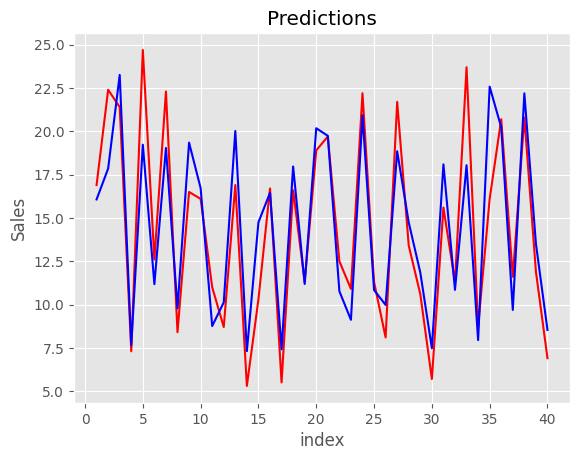

In [43]:
y_pred1 = lr_model1.predict(X_test1)

c = [i for i in range(1, 41, 1)]
plt.plot(c, y_test1, color = 'r') # 실젯값
plt.plot(c, y_pred1, color = 'b') # 예측값
plt.xlabel('index') # X축 이름
plt.ylabel('Sales') # Y축 이름
plt.title('Predictions') # 그래프 제목
plt.show()

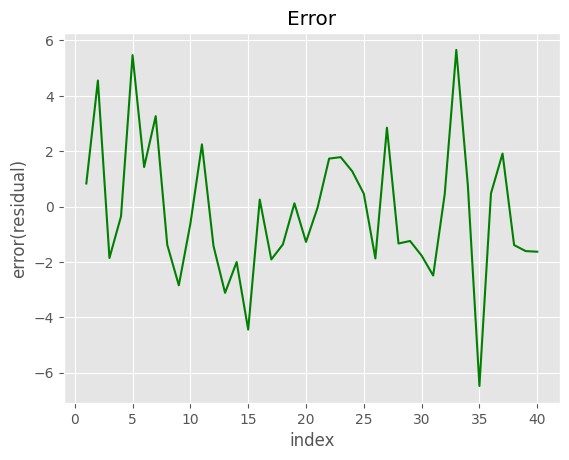

In [45]:
error = y_test1 - y_pred1 # 실젯값 - 예측값 TODO:YOUR_CODE_HERE

plt.plot(c, error, color = 'g')
plt.xlabel('index')
plt.ylabel('error(residual)')
plt.title('Error')
plt.show()

In [ ]:
# 평가 지표 구하기

In [47]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print(f'MSE: {mean_squared_error(y_test1, y_pred1):.2f}') # 평균 제곱 오차(MSE)
print(f'r2_score: {r2_score(y_test1, y_pred1):.2f}') # 결정계수(R2)

MSE: 6.10
r2_score: 0.80


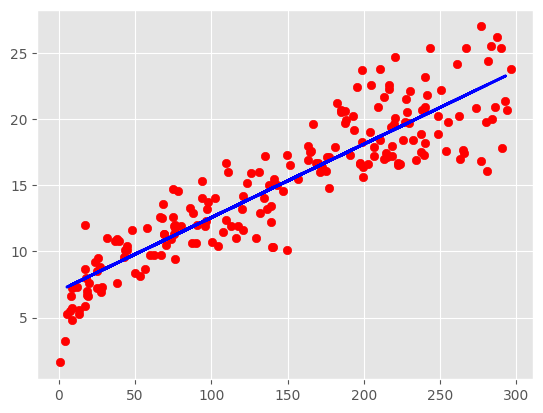

In [49]:
plt.scatter(X_data1, y_data1, color = 'red', label = 'scatter plot')
plt.plot(X_test1, y_pred1, color = 'blue', linewidth = 2, label = 'Regression Line')
plt.show()

In [58]:
# Slope Coefficients(기울기 계수)
w1 = lr_model1.coef_ # 기울기
print(f'slopes of TV: {w1[0]:.2f}')

# Intercept(절편)
b1 = lr_model1.intercept_ # y 절편
print('Intercept is:', b1.round(2))

slopes of TV: 0.06
Intercept is: 7.01


In [60]:
# 새로운 TV광고비를 입력받아 값 예측하기측하기
w1[0] * 100 + b1

np.float64(12.555402821388167)

### 다중 선형 회귀

In [68]:
# 타겟과 속성 분리하기
X_data2 = advertising[['TV','Radio','Newspaper']]# TODO:YOUR_CODE_HERE
y_data2 = advertising['Sales'] # TODO:YOUR_CODE_HERE
print(X_data2)

        TV  Radio  Newspaper
0    230.1   37.8       69.2
1     44.5   39.3       45.1
2     17.2   45.9       69.3
3    151.5   41.3       58.5
4    180.8   10.8       58.4
..     ...    ...        ...
195   38.2    3.7       13.8
196   94.2    4.9        8.1
197  177.0    9.3        6.4
198  283.6   42.0       66.2
199  232.1    8.6        8.7

[200 rows x 3 columns]


<Axes: >

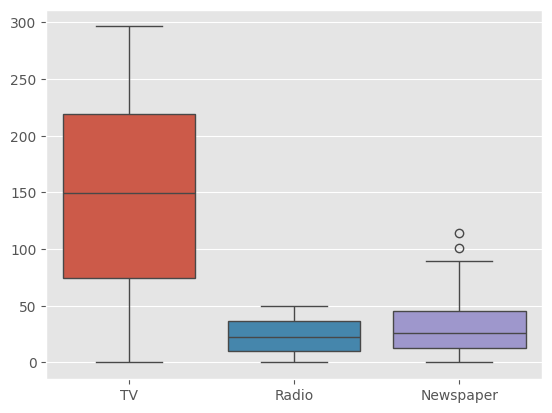

In [63]:
sns.boxplot(X_data2)

In [76]:
# 훈련 데이터와 테스트 데이터를 7:3으로 나누기
# random_state 옵션을 사용하여 훈련 데이터와 테스트 데이터를 동일한 패턴으로 추출하기

from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_data2, y_data2, train_size=0.8, random_state=42)
print(X_train2.shape, X_test2.shape, y_train2.shape, y_test2.shape)


(160, 3) (40, 3) (160,) (40,)


In [78]:
from sklearn.model_selection import train_test_split

# TODO:YOUR_CODE_HERE
print(X_train2.shape, X_test2.shape, y_train2.shape, y_test2.shape)

(160, 3) (40, 3) (160,) (40,)


In [ ]:
# 속성값의 차이가 있으므로 범위를 일정하게 맞춰 주는 표준화 적용하기


In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # TODO:YOUR_CODE_HERE

X_train_scaled = scaler.fit_transform(X_train2) # TODO:YOUR_CODE_HERE
X_test_scaled = scaler.transform(X_test2) # TODO:YOUR_CODE_HERE

In [ ]:
# 모델 생성하고 학습시키기

In [82]:
from sklearn.linear_model import LinearRegression

lr_model2 = LinearRegression() # TODO:YOUR_CODE_HERE
lr_model2.fit(X_train_scaled, y_train2)# TODO:YOUR_CODE_HERE

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [83]:
# 실제값과 예측값을 구해 데이터프레임 형태로 만들기

In [85]:
mlr = pd.DataFrame({'Actual_value': y_test2, 'Model prediction':lr_model2.predict(X_test_scaled)})
mlr.head()

,Actual_value,Model prediction
95,16.9,17.034772
15,22.4,20.409740
30,21.4,23.723989
158,7.3,9.272785
128,24.7,21.682719


In [ ]:
# 실제값과 예측값의 오차를 그래프로 표현

[[ 0.15781217  0.59112727  1.13227461]
 [ 0.53925283  1.68199613  1.13227461]
 [ 1.69783431  0.36753303  0.65380096]
 [-1.64363349  0.95023317  0.75245532]
 [ 0.83513672  1.77007871 -1.31928629]
 [-0.89025846  0.82149709  1.12240918]
 [ 0.79354661  1.42452397 -0.13543394]
 [-1.18851892 -0.76398933 -0.56951314]
 [ 0.86009078 -1.31958713 -0.8309472 ]
 [ 0.29803023 -0.02545078  0.07667294]
 [-1.40835233  0.11683646 -1.36861347]
 [-1.11484502 -1.16374872 -0.01211599]
 [ 1.00387371 -1.31958713  2.70581169]
 [-1.71849568  0.47594236 -1.01345777]
 [-0.12500054 -1.40766971 -0.16503025]
 [ 0.23980408 -1.02146148  0.25918351]
 [-1.69591819  0.35398186  0.56501203]
 [ 0.56539519  0.02875388 -0.7766873 ]
 [-0.88788188 -0.17451361  0.12600012]
 [ 1.03833409  0.31332837 -0.93453428]
 [ 0.94445928  0.63855635  2.18294357]
 [-0.97700354  0.92990642  4.14616538]
 [-1.33111357  1.18060299 -0.89013981]
 [ 1.19875306  0.92313083  2.08922193]
 [-0.96274407 -0.91982774 -1.43273881]
 [-1.14692882 -1.4144453 

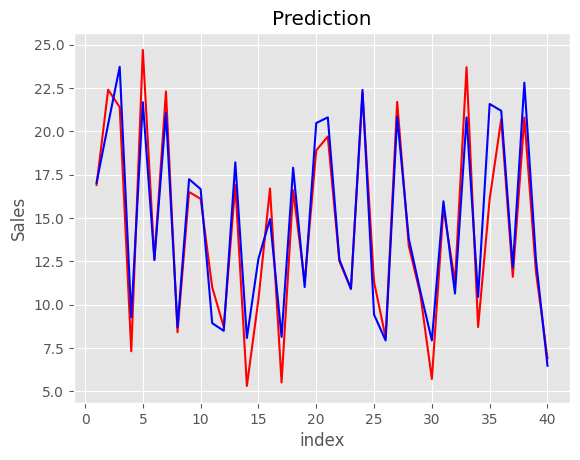

In [105]:
print(X_test_scaled)

y_pred2 = lr_model2.predict(X_test_scaled)
c = [i for i in range(1, 41, 1)]

plt.plot(c, y_test2, color = 'r')
plt.plot(c, y_pred2, color ='b')
plt.xlabel('index')
plt.ylabel('Sales')
plt.title('Prediction')
plt.show()

In [ ]:
# 오차 그래프로 시각화하기

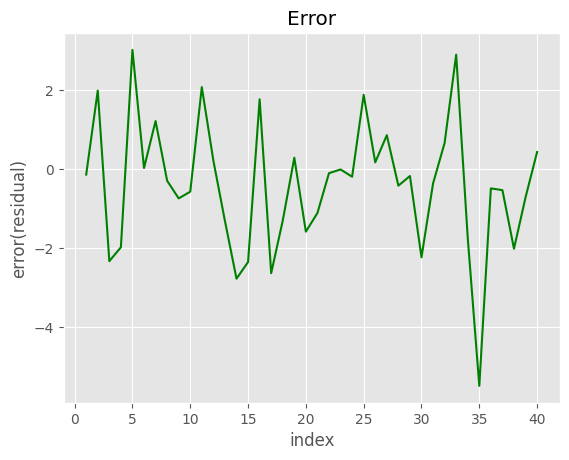

In [97]:
error2 = y_test2 - y_pred2 # TODO:YOUR_CODE_HERE
plt.plot(c, error2, color ='g')
plt.xlabel('index')
plt.ylabel('error(residual)')
plt.title('Error')
plt.show()

In [ ]:
print(f'MSE:{mean_squared_error(y_test2, y_pred2):.2f}')
print(f'r2_score:{r2_score(y_test2, y_pred2):.2f}')


MSE:2.91
r2_score:0.91


In [102]:

w2 = lr_model2.coef_

print(w2)

print(f'Slope of TV: {w2[0]:.2f}')
print(f'Slope of Radio: {w2[1]:.2f}')
print(f'Slope of Newspaper: {w2[2]:.2f}')

# 절편
b2 = lr_model2.intercept_
print(f'Intercept is: {b2:.2f}')

[4.58720774 1.48984025 0.08791597]
Slope of TV: 4.59
Slope of Radio: 1.49
Slope of Newspaper: 0.09
Intercept is: 15.33


In [109]:
# 새로운 값 예측하기 [[180,18,3]]

result = scaler.transform([[180,18,3]])
print(result)
y_pred2 = lr_model2.predict(result)
print(y_pred2)

[[ 0.35625638 -0.33035202 -1.32915173]]
[16.35582162]


In [ ]:
MSE:2.91
r2_score:0.91

### 다항회귀

In [111]:
# 다항회귀
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)

In [131]:
x_train_poly = poly.fit_transform(X_train2)
x_test_poly = poly.transform(X_test2)

scaler = StandardScaler()

x_train_poly_scale = scaler.fit_transform(x_train_poly)
x_test_poly_scale = scaler.transform(x_test_poly)


In [132]:
model = LinearRegression()
model.fit(x_train_poly,y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<Axes: >

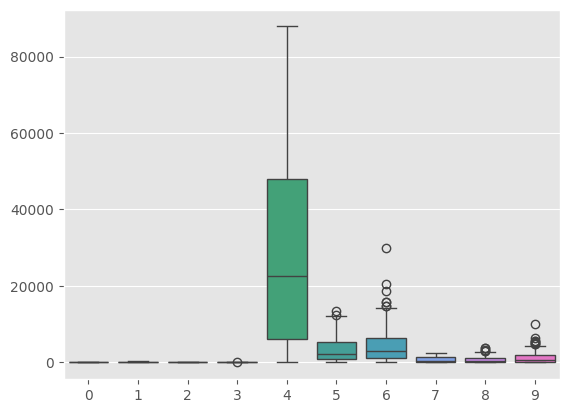

In [127]:
sns.boxplot(x_train_poly)

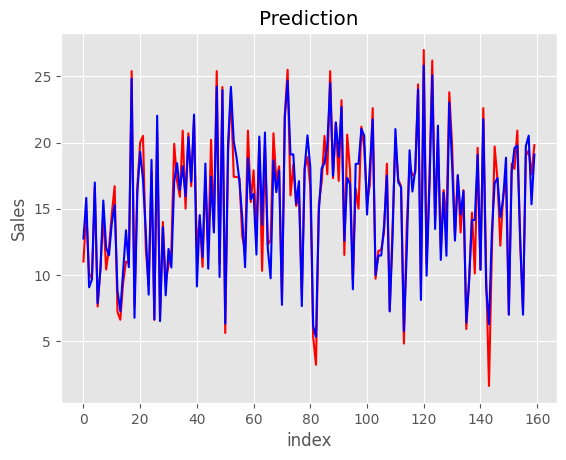

In [136]:
y_pred3 = model.predict(x_train_poly)

c = range(len(y_train2))

# 실제값 vs 예측값
plt.plot(c, y_train2, color='r')
plt.plot(c, y_pred3, color='b')

plt.xlabel('index')
plt.ylabel('Sales')
plt.title('Prediction')
plt.show()

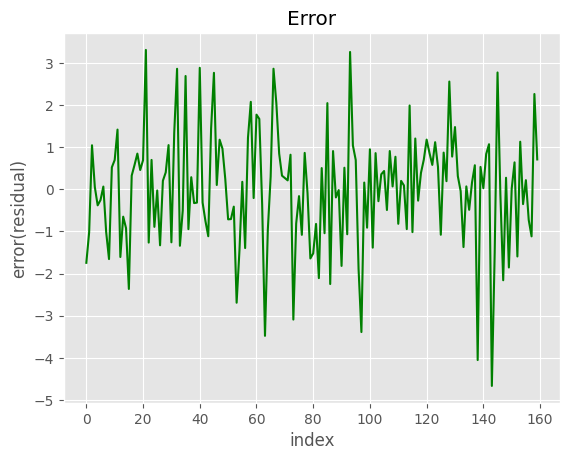

In [137]:
error2 = y_train2 - y_pred3 # TODO:YOUR_CODE_HERE
plt.plot(c, error2, color ='g')
plt.xlabel('index')
plt.ylabel('error(residual)')
plt.title('Error')
plt.show()

In [138]:
print(f'MSE:{mean_squared_error(y_train2, y_pred3):.2f}')
print(f'r2_score:{r2_score(y_train2, y_pred3):.2f}')

MSE:1.91
r2_score:0.93


### 규제

In [ ]:
# 규제